In [48]:
import anndata
import scanpy as sc
import spatialdata as sd
import spatialdata_plot
import squidpy as sq
import celltypist
import numpy as np
from pathlib import Path
import zarr
import anndata as ad
import numpy as np
import pandas as pd
from scipy import sparse
from read_xenium_anndata import read_spatialdata_from_zarr 

In [62]:
# 1. Load Datasets

home = Path.home()


# tissue = "lv_0046706_053.zarr"
# tissue = "lv_0046706_007.zarr" # error
# tissue = "lv_0046706_75_control.zarr"
# tissue = "lv_0046706_71_control.zarr"
# tissue = "lv_0046706_117.zarr" # error
# tissue = "lv_0046859_002.zarr"
# tissue = "lv_0046859_033.zarr"
# tissue = "lv_0046859_039.zarr"
# tissue = "lv_0046859_736_control.zarr"

tissue = "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP.zarr" 





# sdata = sd.read_zarr(home / "datasets/lv_spatialdat_liu" / tissue)
sdata = sd.read_zarr(home / "datasets/10x_xenium_mouse_datasets/zarr_xenosplit" / tissue)
# sdata = read_spatialdata_from_zarr(home / "datasets/10x_xenium_mouse_datasets/zarr_xenosplit" / tissue)

# Load the single-cell reference data
# adata_ref = anndata.read_h5ad(home / "datasets/scRNAseq_skin/d0c12af4-c0e4-4c7b-873a-70752b449689/original_adata.h5ad")
# adata_ref = anndata.read_h5ad(home / "datasets/xenium_ref/0c44ac00-d0a8-4a5d-93e6-da8df2488ad2.h5ad")
adata_ref = anndata.read_h5ad(home / "datasets/xenium_ref/24b8aa1f-258c-4d47-8f96-e30fa8d4aeb0.h5ad")

# Extract the AnnData table from your SpatialData object
adata_xenium = sdata.tables["table"]
# adata_xenium = read_anndata_from_zarr(home / "datasets/10x_xenium_mouse_datasets/zarr" / tissue)


version mismatch: detected: RasterFormatV02, requested: FormatV04
root_attr: multiscales
root_attr: omero
root_attr: spatialdata_attrs
datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}, {'coordinateTransformations': [{'scale': [1.0, 2.0, 2.0], 'type': 'scale'}], 'path': '1'}, {'coordinateTransformations': [{'scale': [1.0, 4.0, 4.0], 'type': 'scale'}], 'path': '2'}, {'coordinateTransformations': [{'scale': [1.0, 8.001922152811149, 8.0], 'type': 'scale'}], 'path': '3'}, {'coordinateTransformations': [{'scale': [1.0, 16.01153846153846, 16.004993757802747], 'type': 'scale'}], 'path': '4'}]
resolution: 0
 - shape ('c', 'y', 'x') = (1, 16652, 25640)
 - chunks =  ['1', '4096 (+ 268)', '4096 (+ 1064)']
 - dtype = uint16
resolution: 1
 - shape ('c', 'y', 'x') = (1, 8326, 12820)
 - chunks =  ['1', '4096 (+ 134)', '4096 (+ 532)']
 - dtype = uint16
resolution: 2
 - shape ('c', 'y', 'x') = (1, 4163, 6410)
 - chunks =  ['1', '4096 (+ 67)', '4096 (+ 2

In [63]:
import pandas as pd

# 1. Create a standardized version of gene IDs in adata_xenium.var
adata_xenium.var['gene_ids_stripped'] = adata_xenium.var['gene_ids'].str.split('.').str[0]

# 2. Determine the source of gene IDs in adata_ref and create a stripped version
if 'feature_id' in adata_ref.var.columns:
    ref_ids_series = adata_ref.var['feature_id']
else:
    ref_ids_series = pd.Series(adata_ref.var.index)
ref_ids_stripped = ref_ids_series.str.split('.').str[0]

# 3. Find the set of common genes using the standardized IDs
intersecting_genes = set(adata_xenium.var['gene_ids_stripped']).intersection(set(ref_ids_stripped))
print(f"Successfully found {len(intersecting_genes)} common genes after standardizing IDs.")

# 4. Filter adata_ref to keep only the rows corresponding to the common genes
adata_ref_mask = ref_ids_stripped.isin(intersecting_genes)
adata_ref = adata_ref[:, adata_ref_mask].copy()
print(f"Filtered adata_ref. It now has {adata_ref.n_vars} variables.")

# 5. Create the mapping from standardized ID to gene symbol
# We create a Series where the index is the stripped ID and the value is the gene symbol.
# This is the correct format for the .map() function.
gene_id_to_name_map = pd.Series(
    adata_xenium.var.index.values, 
    index=adata_xenium.var['gene_ids_stripped']
).drop_duplicates()


# 6. Set the index of the filtered adata_ref.var to be the gene symbols
# First, get the standardized IDs from the *newly filtered* adata_ref
if 'feature_id' in adata_ref.var.columns:
    filtered_ref_ids_stripped = adata_ref.var['feature_id'].str.split('.').str[0]
else:
    filtered_ref_ids_stripped = pd.Series(adata_ref.var.index).str.split('.').str[0]

# Map the standardized IDs to the gene symbols to create the new index
adata_ref.var.index = filtered_ref_ids_stripped.map(gene_id_to_name_map)
adata_ref.var.index.name = 'gene_symbol'

# 7. Clean up the temporary column
del adata_xenium.var['gene_ids_stripped']

# Display the head of the updated adata_ref.var to verify the result
print("\nUpdated adata_ref.var:")
print(adata_ref.var.head())

Successfully found 248 common genes after standardizing IDs.
Filtered adata_ref. It now has 248 variables.

Updated adata_ref.var:
                 feature_types genome  feature_is_filtered feature_name  \
gene_symbol                                                               
Sox17          Gene Expression   mm10                False        Sox17   
Col19a1        Gene Expression   mm10                False      Col19a1   
2010300C02Rik  Gene Expression   mm10                False       Cracdl   
Satb2          Gene Expression   mm10                False        Satb2   
Nrp2           Gene Expression   mm10                False         Nrp2   

              feature_reference feature_biotype feature_length    feature_type  
gene_symbol                                                                     
Sox17           NCBITaxon:10090            gene           1509  protein_coding  
Col19a1         NCBITaxon:10090            gene           4266  protein_coding  
2010300C02Rik   NCB

In [53]:
# 2. Harmonize Genes
# ------------------
# Annotation models require the exact same set of genes (var_names)
# in the reference and query data.
print(f"Genes in Xenium data: {adata_xenium.n_vars}")
print(f"Genes in reference data: {adata_ref.n_vars}")

# Find the intersection of genes
common_genes = adata_ref.var_names.intersection(adata_xenium.var_names)
print(f"Found {len(common_genes)} common genes.")

# It's critical to have a sufficient number of overlapping genes.
# A Xenium panel is small (~300-500 genes), so this overlap is key.
if len(common_genes) < 50:
    print("⚠️ Warning: Very few common genes. Annotation quality will be poor.")

# Subset both AnnData objects to the common genes
adata_ref = adata_ref[:, common_genes].copy()
adata_xenium = adata_xenium[:, common_genes].copy()


Genes in Xenium data: 248
Genes in reference data: 248
Found 248 common genes.


In [64]:
# 3. Train the Annotation Model
# -----------------------------
# Normalize the data before training/prediction.
# The training data (adata_ref) needs to be normalized.
sc.pp.normalize_total(adata_ref, target_sum=1e4)
sc.pp.log1p(adata_ref)

# Train the celltypist model on the reference data
# Specify the gene expression data (`adata_ref`) and the labels (`obs['cell_type']`).
model = celltypist.train(adata_ref, labels="cell_type", feature_selection=False)

# normalize adata_xenium later before prediction
sc.pp.normalize_total(adata_xenium, target_sum=1e4)
sc.pp.log1p(adata_xenium)

print("Model training complete.")

🍳 Preparing data before training
✂️ 12 non-expressed genes are filtered out
🔬 Input data has 4992 cells and 236 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
✅ Model training done!


Model training complete.


In [65]:
# 4. Predict Cell Types on Xenium Data
# ------------------------------------
# Use the trained model to predict cell types on the Xenium data
# The correct function is `celltypist.annotate`, not `celltypist.predict`.
predictions = celltypist.annotate(adata_xenium, model=model)

print(predictions.predicted_labels.head())

🔬 Input data has 36602 cells and 248 genes
🔗 Matching reference genes in the model
🧬 236 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  predicted_labels
0   enteric neuron
1       enterocyte
2       enterocyte
3       enterocyte
4   enteric neuron


In [66]:
# 5. Add Annotations to SpatialData
# ---------------------------------
# The `predictions.predicted_labels` DataFrame is indexed by cell ID,
# matching the index of `sdata.tables["table"].obs`. We can assign the
# 'predicted_labels' column directly to our main SpatialData object.

sdata.tables["table"].obs['cell_type_predicted'] = predictions.predicted_labels['predicted_labels']

# Verify the column has been added successfully
print("Columns in sdata.tables['table'].obs:")
print(sdata.tables["table"].obs.columns)

print("\nFirst 5 predicted cell types:")
print(sdata.tables["table"].obs['cell_type_predicted'].head())

Columns in sdata.tables['table'].obs:
Index(['cell_id', 'transcript_counts', 'control_probe_counts',
       'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area',
       'region', 'cell_type_predicted'],
      dtype='object')

First 5 predicted cell types:
0    enteric neuron
1        enterocyte
2        enterocyte
3        enterocyte
4    enteric neuron
Name: cell_type_predicted, dtype: category
Categories (11, object): ['CD103-positive dendritic cell', 'enteric neuron', 'enterocyte', 'fibroblast', ..., 'myofibroblast cell', 'stem cell', 'transit amplifying cell', 'unknown']


Aligning table data with the 'cell_boundaries' shapes element...
Setting the final, validated metadata...
Ensuring the annotation column is the correct data type...
Generating the final plot...


/var/folders/xz/289tk8xn6zl90c3p1t1jpwxw0000gn/T/ipykernel_218/3352723854.py:9: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = 'cell_boundaries'
/var/folders/xz/289tk8xn6zl90c3p1t1jpwxw0000gn/T/ipykernel_218/3352723854.py:10: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')
/var/folders/xz/289tk8xn6zl90c3p1t1jpwxw0000gn/T/ipykernel_218/3352723854.py:10: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')
/var/folders/xz/289tk8xn6zl90c3p1t1jpwxw0000gn/T/ipykernel_218/3352723854.py:14: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.uns['spatialdata_attrs'] 

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


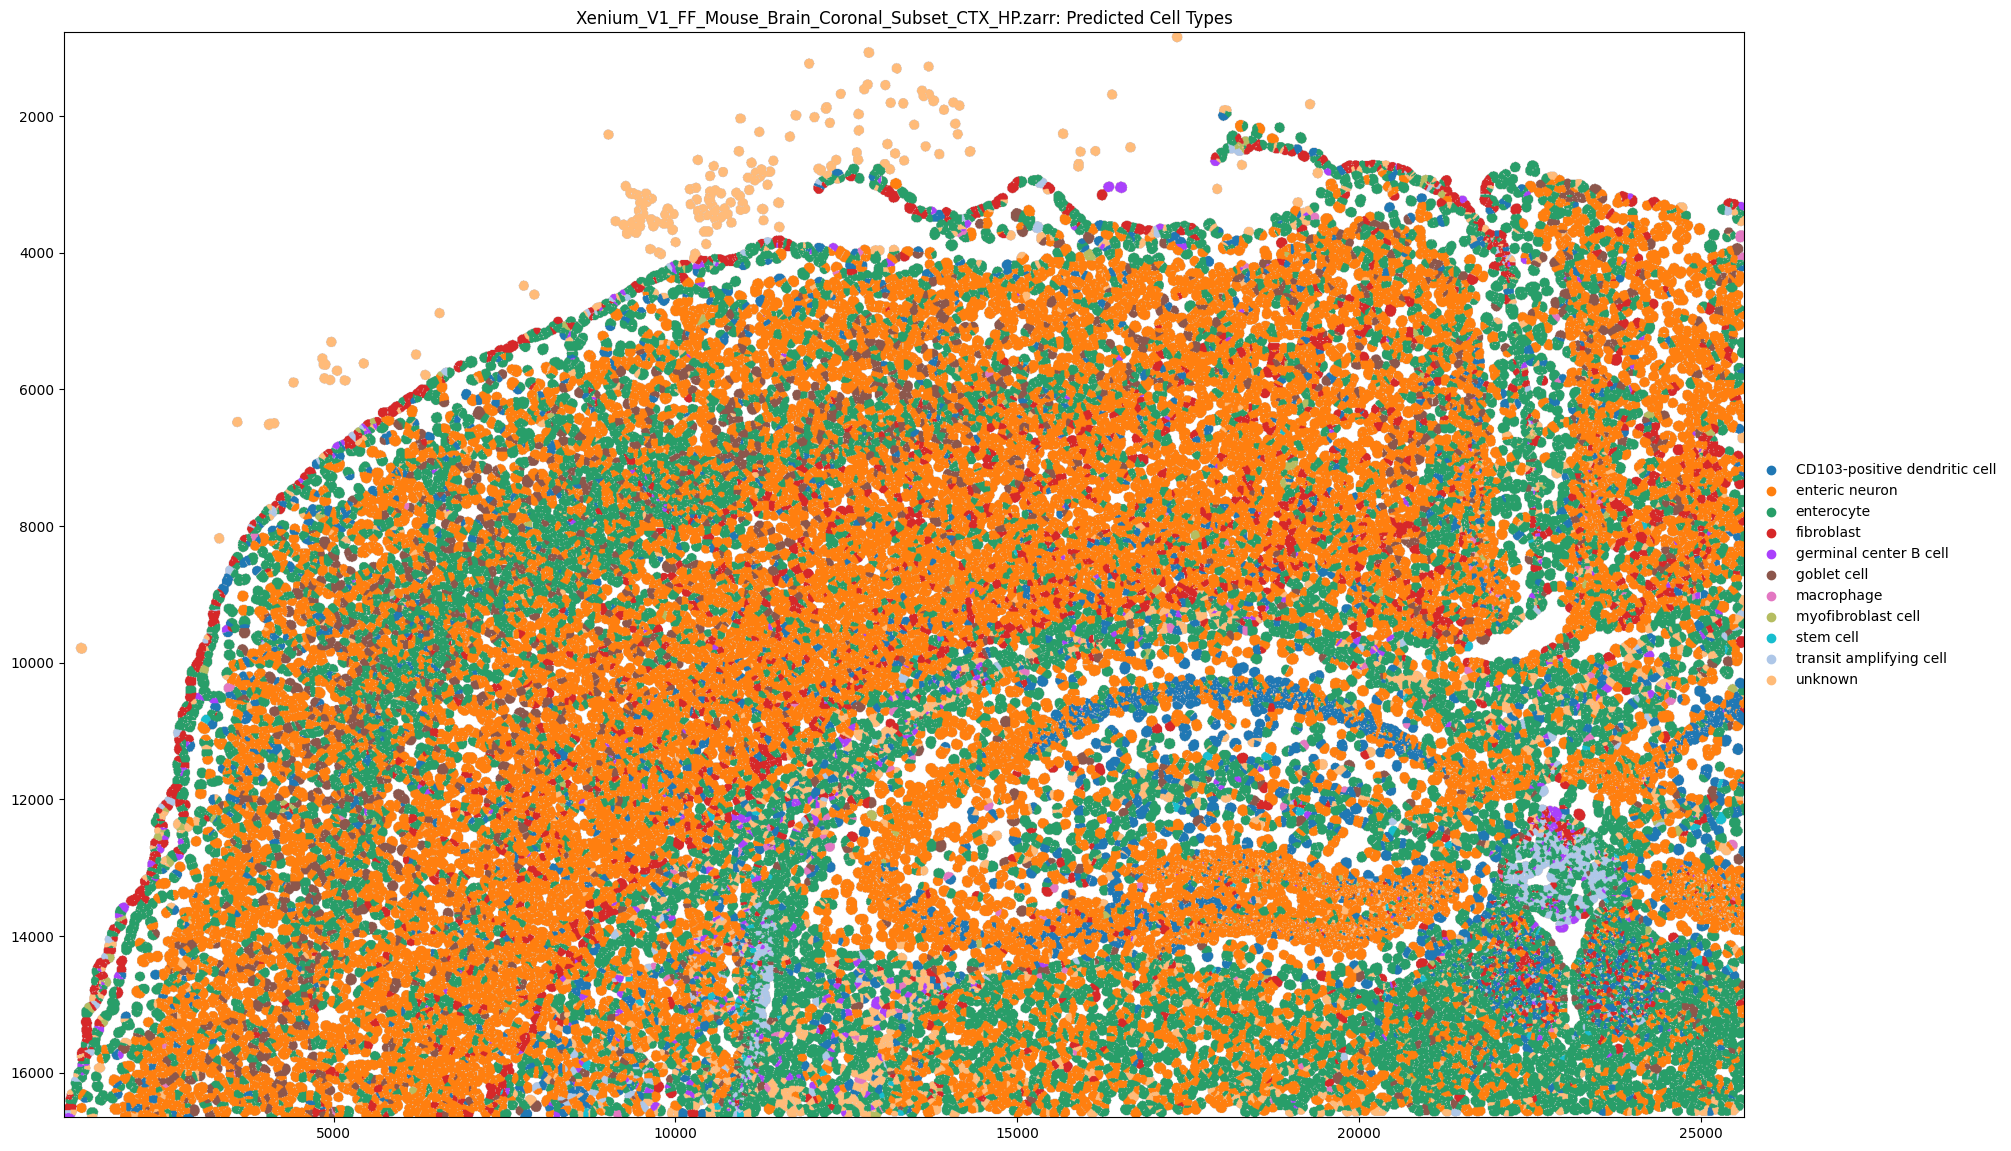

In [67]:
# 6. Save and Visualize (Final Data Integrity Fix)
# -----------------------------------------------
# The ValidationError indicates a mismatch between the table's 'region' column
# and the metadata. We will now fix the data itself to ensure it is valid.

# Align the table's region column with the shapes element ---
# We force every row in the table to explicitly state it belongs to 'cell_boundaries'.
print("Aligning table data with the 'cell_boundaries' shapes element...")
sdata.table.obs['region'] = 'cell_boundaries'
sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')

# Now that the data is clean, we set the metadata to match it perfectly.
print("Setting the final, validated metadata...")
sdata.table.uns['spatialdata_attrs'] = {
    'region': 'cell_boundaries',
    'region_key': 'region',
    'instance_key': 'cell_id'
}

# Ensure the color column is 'category' dtype ---
print("Ensuring the annotation column is the correct data type...")
sdata.table.obs['cell_type_predicted'] = sdata.table.obs['cell_type_predicted'].astype('category')

# With the data and metadata now fully validated, the plot will render.
print("Generating the final plot...")
# sdata.pl.render_images(
#     element="morphology_focus",
#     alpha=0.5
# )
sdata.pl.render_shapes(
    element="cell_boundaries",
    color="cell_type_predicted",
    legend_kwargs={"loc": "upper left", "bbox_to_anchor": (1, 1)},
    legend_fontsize=8
).pl.show(
    title=tissue + ": Predicted Cell Types" ,
    figsize=(20, 20)
)

In [68]:
# Create a deep copy of the original sdata
import spatialdata as sd
from copy import deepcopy

# Create a deep copy of the SpatialData object
sdata_endothelial = deepcopy(sdata)

# Filter the table to keep only endothelial cells
endothelial_mask = sdata_endothelial.tables["table"].obs['cell_type_predicted'] == 'endothelial cell'
sdata_endothelial.tables["table"] = sdata_endothelial.tables["table"][endothelial_mask].copy()

# Verify the filtering
print("Original number of cells:", len(sdata.tables["table"]))
print("Number of endothelial cells:", len(sdata_endothelial.tables["table"]))

# Check the unique cell types in the filtered data
print("\nCell types in filtered data:")
print(sdata_endothelial.tables["table"].obs['cell_type_predicted'].unique())

ValueError: Regions in the AnnData object and `region` do not match.

In [69]:
adata = sdata_endothelial.tables["table"]
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)
sq.gr.spatial_neighbors(adata)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/Users/chrism/git/spatialdata-notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


... storing 'segmentation_method' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


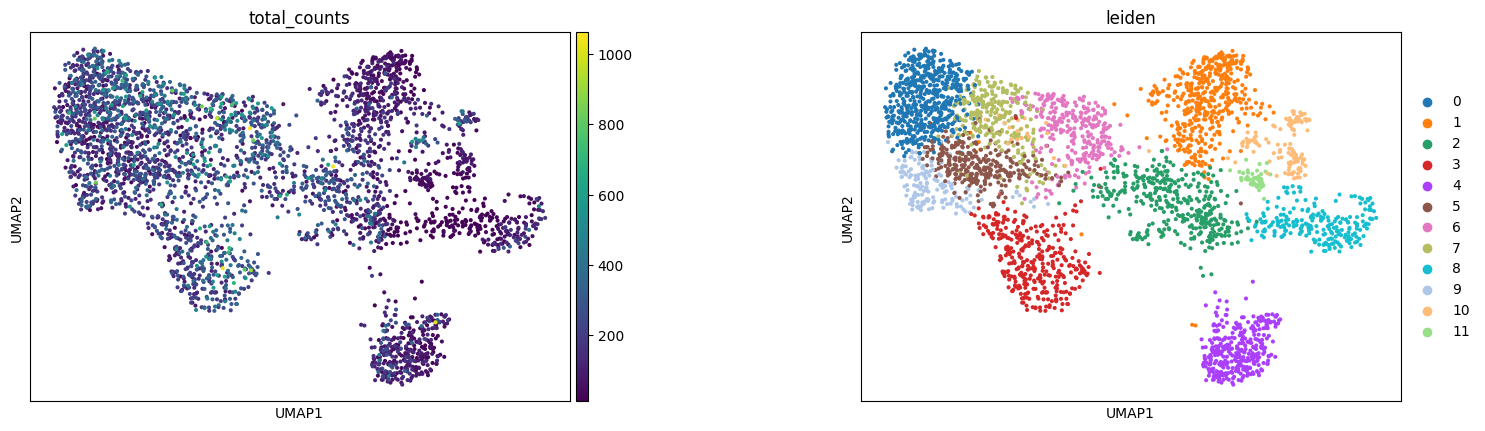

In [11]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "leiden",
    ],
    wspace=0.4
)

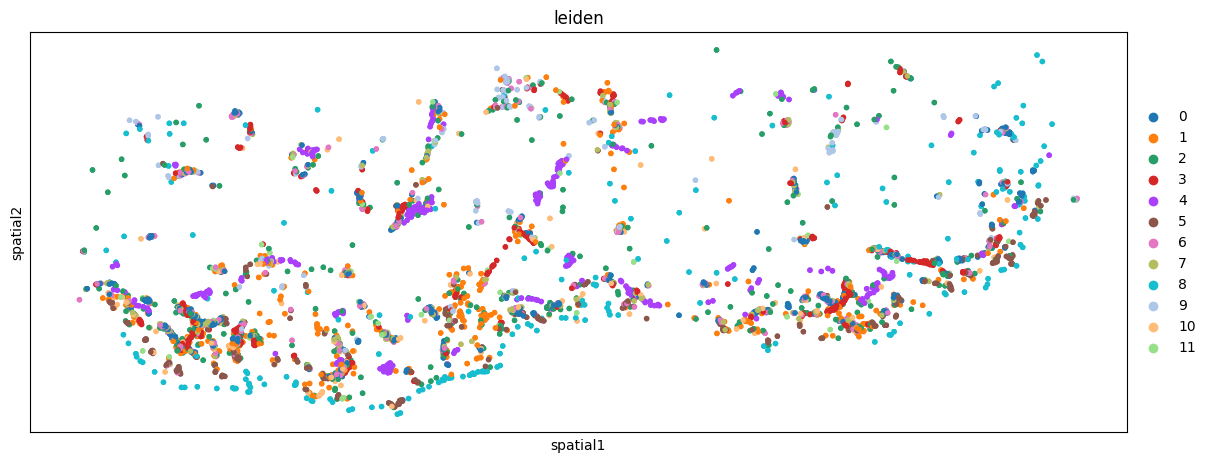

In [12]:
adata.uns.pop('leiden_colors')
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
    figsize=(12, 12)
)


In [13]:
# Calculate total transcripts for each individual cell
adata.obs['n_transcripts'] = np.array(adata.X.sum(axis=1)).flatten()

# Group by cluster and calculate the mean
avg_transcripts_per_cell = adata.obs.groupby('leiden')['n_transcripts'].mean()

print("\nAverage number of transcripts per cell in each cluster:")
print(avg_transcripts_per_cell)


Average number of transcripts per cell in each cluster:
leiden
0     53.575703
1     54.287426
2     54.780785
3     61.728188
4     51.091003
5     56.061363
6     63.131855
7     59.303509
8     33.915596
9     56.366837
10    55.191547
11    41.590141
Name: n_transcripts, dtype: float32


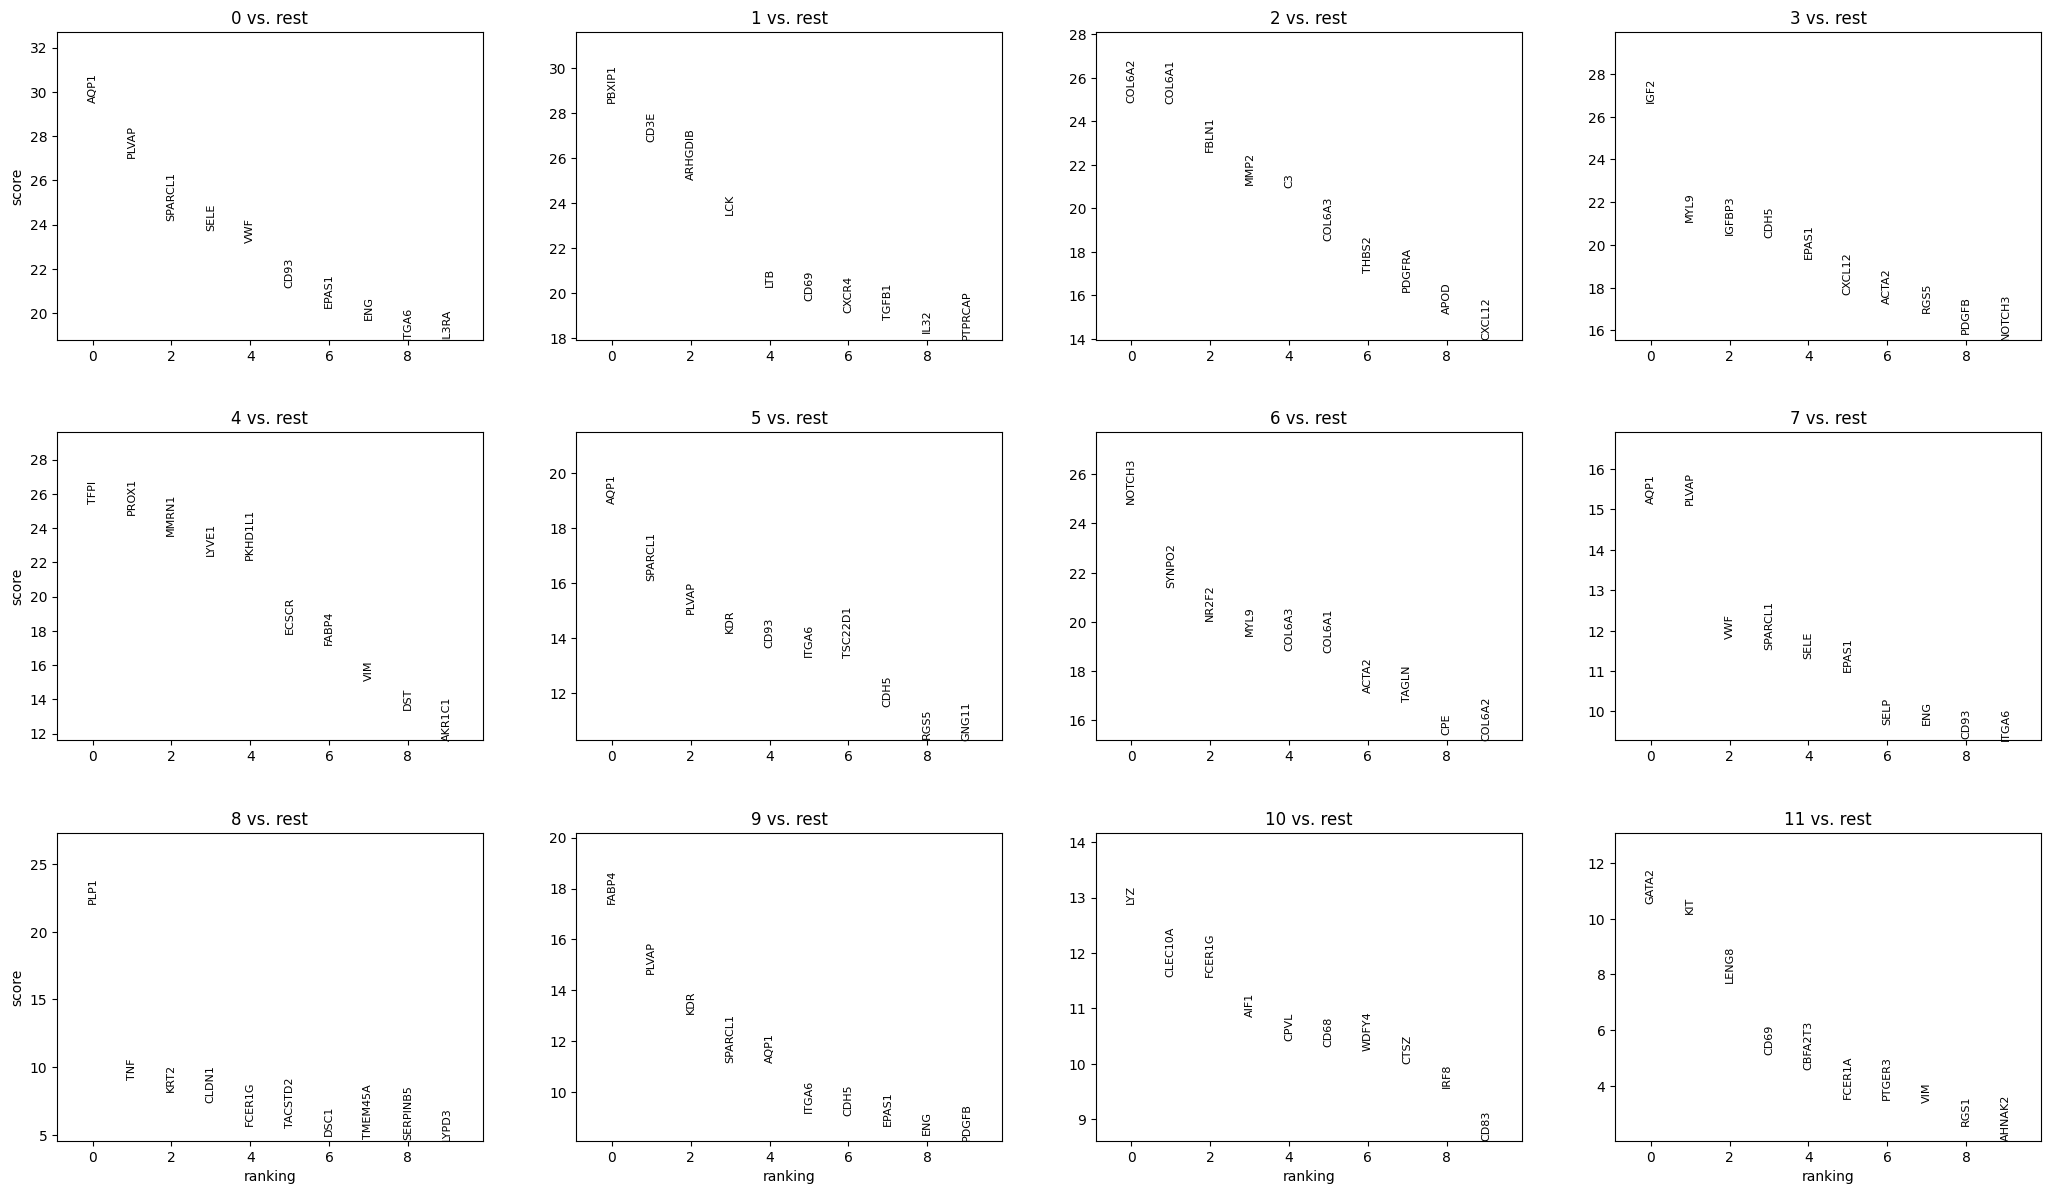


Top marker genes for each cluster:
         0        1       2       3        4        5       6        7  \
0     AQP1   PBXIP1  COL6A2    IGF2     TFPI     AQP1  NOTCH3     AQP1   
1    PLVAP     CD3E  COL6A1    MYL9    PROX1  SPARCL1  SYNPO2    PLVAP   
2  SPARCL1  ARHGDIB   FBLN1  IGFBP3    MMRN1    PLVAP   NR2F2      VWF   
3     SELE      LCK    MMP2    CDH5    LYVE1      KDR    MYL9  SPARCL1   
4      VWF      LTB      C3   EPAS1  PKHD1L1     CD93  COL6A3     SELE   

        8        9       10       11  
0    PLP1    FABP4      LYZ    GATA2  
1     TNF    PLVAP  CLEC10A      KIT  
2    KRT2      KDR   FCER1G    LENG8  
3   CLDN1  SPARCL1     AIF1     CD69  
4  FCER1G     AQP1     CPVL  CBFA2T3  


In [14]:
# Use scanpy's rank_genes_groups to find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Visualize the top marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

# You can also get the marker genes as a DataFrame
marker_genes_df = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
print("\nTop marker genes for each cluster:")
print(marker_genes_df.head())